# 6.3.2 误分类样本与类别混淆分析

本 Notebook 直接读取 **6.3.1 已保存的测试集预测明细**，不重新训练模型，也不重复执行测试集推理。  
主要分析类别错误率、主要混淆方向、置信度差异，以及代表性误分类与低置信度正确样本。

In [1]:
# ==========================================
# Cell 2：环境、路径、字体与预测结果读取
# ==========================================
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.font_manager import FontProperties
from IPython.display import display, Image as IPythonImage

PROJECT_ROOT_CANDIDATES = [
    Path("/root/autodl-tmp/课设"),
    Path("/root/autodl-tmp/.autodl/课设"),
]
PROJECT_ROOT = next(
    (path for path in PROJECT_ROOT_CANDIDATES if path.is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "未找到课设项目根目录。已检查：\n"
        + "\n".join(str(path) for path in PROJECT_ROOT_CANDIDATES)
    )

TEST_RESULT_DIR = (
    PROJECT_ROOT / "results" / "06_模型训练与优化"
    / "6.3.1_最终模型测试集性能评估"
)
OUTPUT_DIR = (
    PROJECT_ROOT / "results" / "06_模型训练与优化"
    / "6.3.2_误分类样本与类别混淆分析"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREDICTION_PATH = TEST_RESULT_DIR / "02_测试集预测明细.csv"

CLASS_NAMES_CN = [
    "年生作物地", "永久性作物地", "森林", "草本植被", "牧场",
    "高速公路", "工业区", "居民区", "河流", "海洋与湖泊",
]

def configure_chinese_font():
    candidates = [
        Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"),
        Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc"),
        Path("/usr/share/fonts/truetype/wqy/wqy-microhei.ttc"),
        Path("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"),
    ]
    font_path = next((path for path in candidates if path.is_file()), None)
    if font_path is None:
        warnings.warn("未找到中文字体，图中中文可能显示异常。")
        return None
    font_manager.fontManager.addfont(str(font_path))
    font_name = FontProperties(fname=str(font_path)).get_name()
    plt.rcParams["font.family"] = font_name
    plt.rcParams["font.sans-serif"] = [font_name]
    return font_path

CHINESE_FONT_PATH = configure_chinese_font()
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 220

def read_csv_flexible(path, **kwargs):
    last_error = None
    for encoding in ("utf-8-sig", "utf-8", "gb18030", "gbk"):
        try:
            return pd.read_csv(path, encoding=encoding, **kwargs)
        except UnicodeDecodeError as error:
            last_error = error
    raise RuntimeError(f"无法读取CSV编码：{path}\n最后错误：{last_error}")

def parse_boolean_series(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)

    text = series.astype(str).str.strip().str.lower()
    mapping = {
        "true": True, "false": False,
        "1": True, "0": False,
        "yes": True, "no": False,
        "是": True, "否": False,
    }
    converted = text.map(mapping)

    numeric = pd.to_numeric(series, errors="coerce")
    numeric_boolean = numeric.map(
        lambda value: bool(value) if pd.notna(value) else np.nan
    )
    converted = converted.where(converted.notna(), numeric_boolean)
    if converted.isna().any():
        bad_values = series.loc[converted.isna()].drop_duplicates().tolist()
        raise ValueError(f"无法识别“是否预测正确”字段中的值：{bad_values[:10]}")
    return converted.astype(bool)

def resolve_prediction_image_path(raw_path):
    text = str(raw_path).strip().replace("\\", "/")
    raw = Path(text)
    candidates = []
    if raw.is_absolute():
        candidates.append(raw)
    candidates.extend([
        PROJECT_ROOT / text,
        PROJECT_ROOT / "EuroSAT_RGB" / text,
        PROJECT_ROOT / "EuroSAT_RGB" / "data" / text,
    ])

    lower = text.lower()
    for marker in ("eurosat_rgb/", "data/"):
        if marker in lower:
            index = lower.index(marker)
            suffix = text[index:]
            candidates.append(PROJECT_ROOT / suffix)
            if marker == "data/":
                candidates.append(PROJECT_ROOT / "EuroSAT_RGB" / suffix)

    for candidate in candidates:
        if candidate.is_file():
            return str(candidate.resolve())
    return str(raw)

if not PREDICTION_PATH.is_file():
    raise FileNotFoundError(
        "未找到6.3.1生成的测试集预测明细，请先完整运行6.3.1：\n"
        f"{PREDICTION_PATH}"
    )

prediction_df = read_csv_flexible(PREDICTION_PATH, low_memory=False)
required_columns = [
    "图像路径", "真实类别索引", "真实类别中文名称",
    "预测类别索引", "预测类别中文名称",
    "预测置信度", "是否预测正确",
]
missing_columns = [
    column for column in required_columns
    if column not in prediction_df.columns
]
if missing_columns:
    raise KeyError(
        "测试集预测明细缺少字段：\n"
        + "\n".join(missing_columns)
    )

prediction_df["是否预测正确"] = parse_boolean_series(
    prediction_df["是否预测正确"]
)
prediction_df["预测置信度"] = pd.to_numeric(
    prediction_df["预测置信度"], errors="raise"
)
prediction_df["真实类别索引"] = pd.to_numeric(
    prediction_df["真实类别索引"], errors="raise"
).astype(int)
prediction_df["预测类别索引"] = pd.to_numeric(
    prediction_df["预测类别索引"], errors="raise"
).astype(int)
prediction_df["图像路径"] = prediction_df["图像路径"].map(
    resolve_prediction_image_path
)

missing_image_count = int(
    (~prediction_df["图像路径"].map(lambda path: Path(path).is_file())).sum()
)
if missing_image_count:
    warnings.warn(
        f"预测明细中有{missing_image_count}张图像路径无法定位。"
        "统计分析仍可继续，样本网格将跳过缺失图像。"
    )

print("=" * 76)
print("6.3.2 误分类样本与类别混淆分析")
print("=" * 76)
print(f"项目根目录：{PROJECT_ROOT}")
print(f"测试样本总数：{len(prediction_df):,}")
print(f"正确预测数量：{int(prediction_df['是否预测正确'].sum()):,}")
print(f"误分类样本数：{int((~prediction_df['是否预测正确']).sum()):,}")
print(f"输出目录：{OUTPUT_DIR}")


6.3.2 误分类样本与类别混淆分析
项目根目录：/root/autodl-tmp/课设
测试样本总数：4,050
正确预测数量：3,982
误分类样本数：68
输出目录：/root/autodl-tmp/课设/results/06_模型训练与优化/6.3.2_误分类样本与类别混淆分析


,真实类别索引,真实类别中文名称,样本数量,正确数量,平均置信度,错误数量,错误率
0,3,草本植被,450,434,0.984376,16,0.035556
1,1,永久性作物地,375,362,0.989793,13,0.034667
2,8,河流,375,366,0.994564,9,0.024000
3,4,牧场,300,294,0.991574,6,0.020000
4,0,年生作物地,450,443,0.993200,7,0.015556
5,5,高速公路,375,370,0.997044,5,0.013333
6,7,居民区,450,445,0.999625,5,0.011111
7,6,工业区,375,371,0.996886,4,0.010667
8,2,森林,450,447,0.999020,3,0.006667
9,9,海洋与湖泊,450,450,0.999465,0,0.000000


,真实类别索引,真实类别中文名称,预测类别索引,预测类别中文名称,混淆数量,平均错误置信度,最高错误置信度
0,1,永久性作物地,0,年生作物地,7,0.938721,1.000000
1,8,河流,5,高速公路,7,0.904312,0.999996
2,3,草本植被,1,永久性作物地,6,0.917464,0.997489
3,0,年生作物地,1,永久性作物地,6,0.840597,0.999320
4,3,草本植被,2,森林,5,0.822168,0.989487
5,3,草本植被,4,牧场,4,0.826534,0.999706
6,2,森林,3,草本植被,3,0.917187,0.996123
7,4,牧场,0,年生作物地,3,0.852875,0.999919
8,7,居民区,5,高速公路,2,0.995536,0.995566
9,1,永久性作物地,3,草本植被,2,0.983997,0.999432


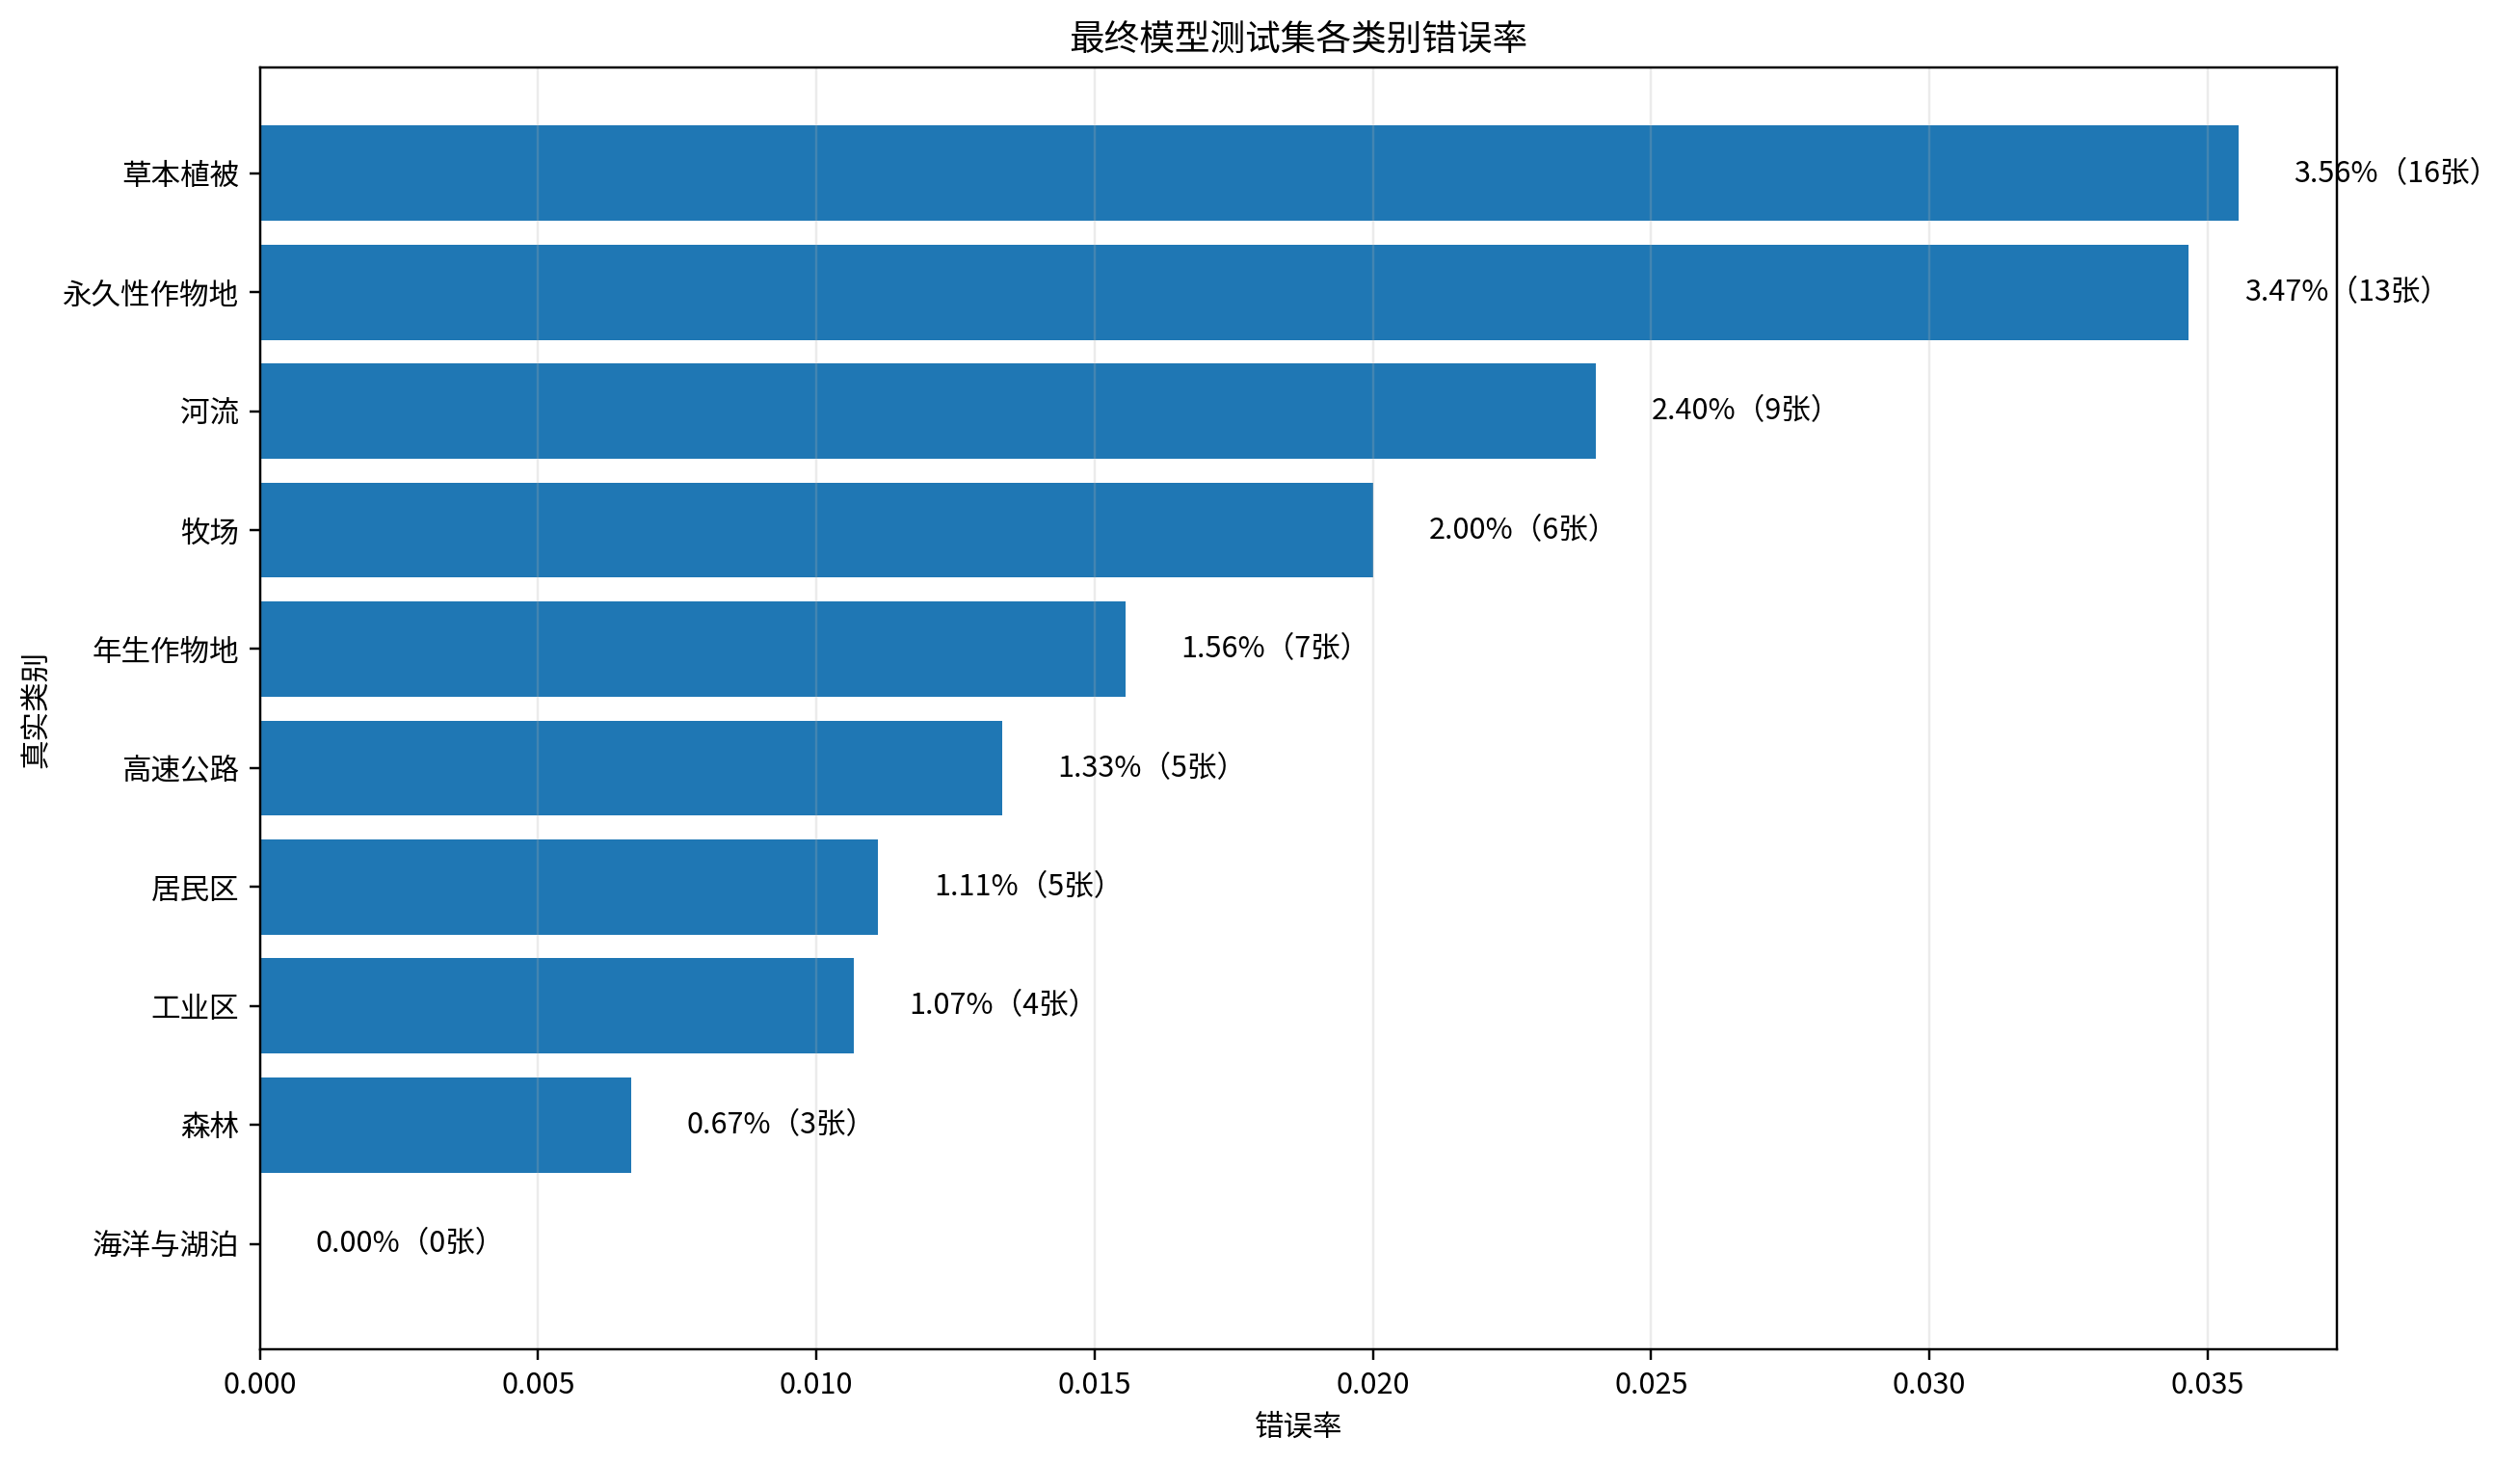

In [2]:
# ==========================================
# Cell 3：类别错误率与主要混淆方向
# ==========================================
class_error_df = (
    prediction_df
    .groupby(["真实类别索引", "真实类别中文名称"], as_index=False)
    .agg(
        样本数量=("是否预测正确", "size"),
        正确数量=("是否预测正确", "sum"),
        平均置信度=("预测置信度", "mean"),
    )
)
class_error_df["正确数量"] = class_error_df["正确数量"].astype(int)
class_error_df["错误数量"] = (
    class_error_df["样本数量"] - class_error_df["正确数量"]
)
class_error_df["错误率"] = np.divide(
    class_error_df["错误数量"],
    class_error_df["样本数量"],
    out=np.zeros(len(class_error_df), dtype=float),
    where=class_error_df["样本数量"].to_numpy() != 0,
)
class_error_df = (
    class_error_df
    .sort_values(["错误率", "错误数量"], ascending=[False, False])
    .reset_index(drop=True)
)

display(class_error_df)
class_error_df.to_csv(
    OUTPUT_DIR / "01_各类别错误率统计.csv",
    index=False,
    encoding="utf-8-sig",
)

error_df = prediction_df.loc[
    ~prediction_df["是否预测正确"]
].copy()

if len(error_df):
    confusion_pairs_df = (
        error_df
        .groupby([
            "真实类别索引", "真实类别中文名称",
            "预测类别索引", "预测类别中文名称",
        ], as_index=False)
        .agg(
            混淆数量=("图像路径", "size"),
            平均错误置信度=("预测置信度", "mean"),
            最高错误置信度=("预测置信度", "max"),
        )
        .sort_values(
            ["混淆数量", "平均错误置信度"],
            ascending=[False, False],
        )
        .reset_index(drop=True)
    )
else:
    confusion_pairs_df = pd.DataFrame(columns=[
        "真实类别索引", "真实类别中文名称",
        "预测类别索引", "预测类别中文名称",
        "混淆数量", "平均错误置信度", "最高错误置信度",
    ])

display(confusion_pairs_df.head(20))
confusion_pairs_df.to_csv(
    OUTPUT_DIR / "02_类别混淆方向统计.csv",
    index=False,
    encoding="utf-8-sig",
)

# 类别错误率图
plt.close("all")
figure, axis = plt.subplots(figsize=(12, 7))
ordered = class_error_df.sort_values("错误率", ascending=True)
bars = axis.barh(ordered["真实类别中文名称"], ordered["错误率"])
axis.set_xlabel("错误率")
axis.set_ylabel("真实类别")
axis.set_title("最终模型测试集各类别错误率")
axis.grid(axis="x", alpha=0.25)

for bar, value, count in zip(
    bars,
    ordered["错误率"],
    ordered["错误数量"],
):
    axis.text(
        value + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2%}（{int(count)}张）",
        va="center",
        fontsize=10,
    )

figure.tight_layout()
ERROR_RATE_FIGURE_PATH = OUTPUT_DIR / "03_各类别错误率.png"
figure.savefig(ERROR_RATE_FIGURE_PATH, dpi=220, bbox_inches="tight")
plt.close(figure)

display(IPythonImage(filename=str(ERROR_RATE_FIGURE_PATH)))


,预测结果,样本数量,平均置信度,中位数置信度,最低置信度,最高置信度
0,正确预测,3982,0.996677,1.000000,0.515645,1.0
1,错误预测,68,0.876760,0.957933,0.503906,1.0


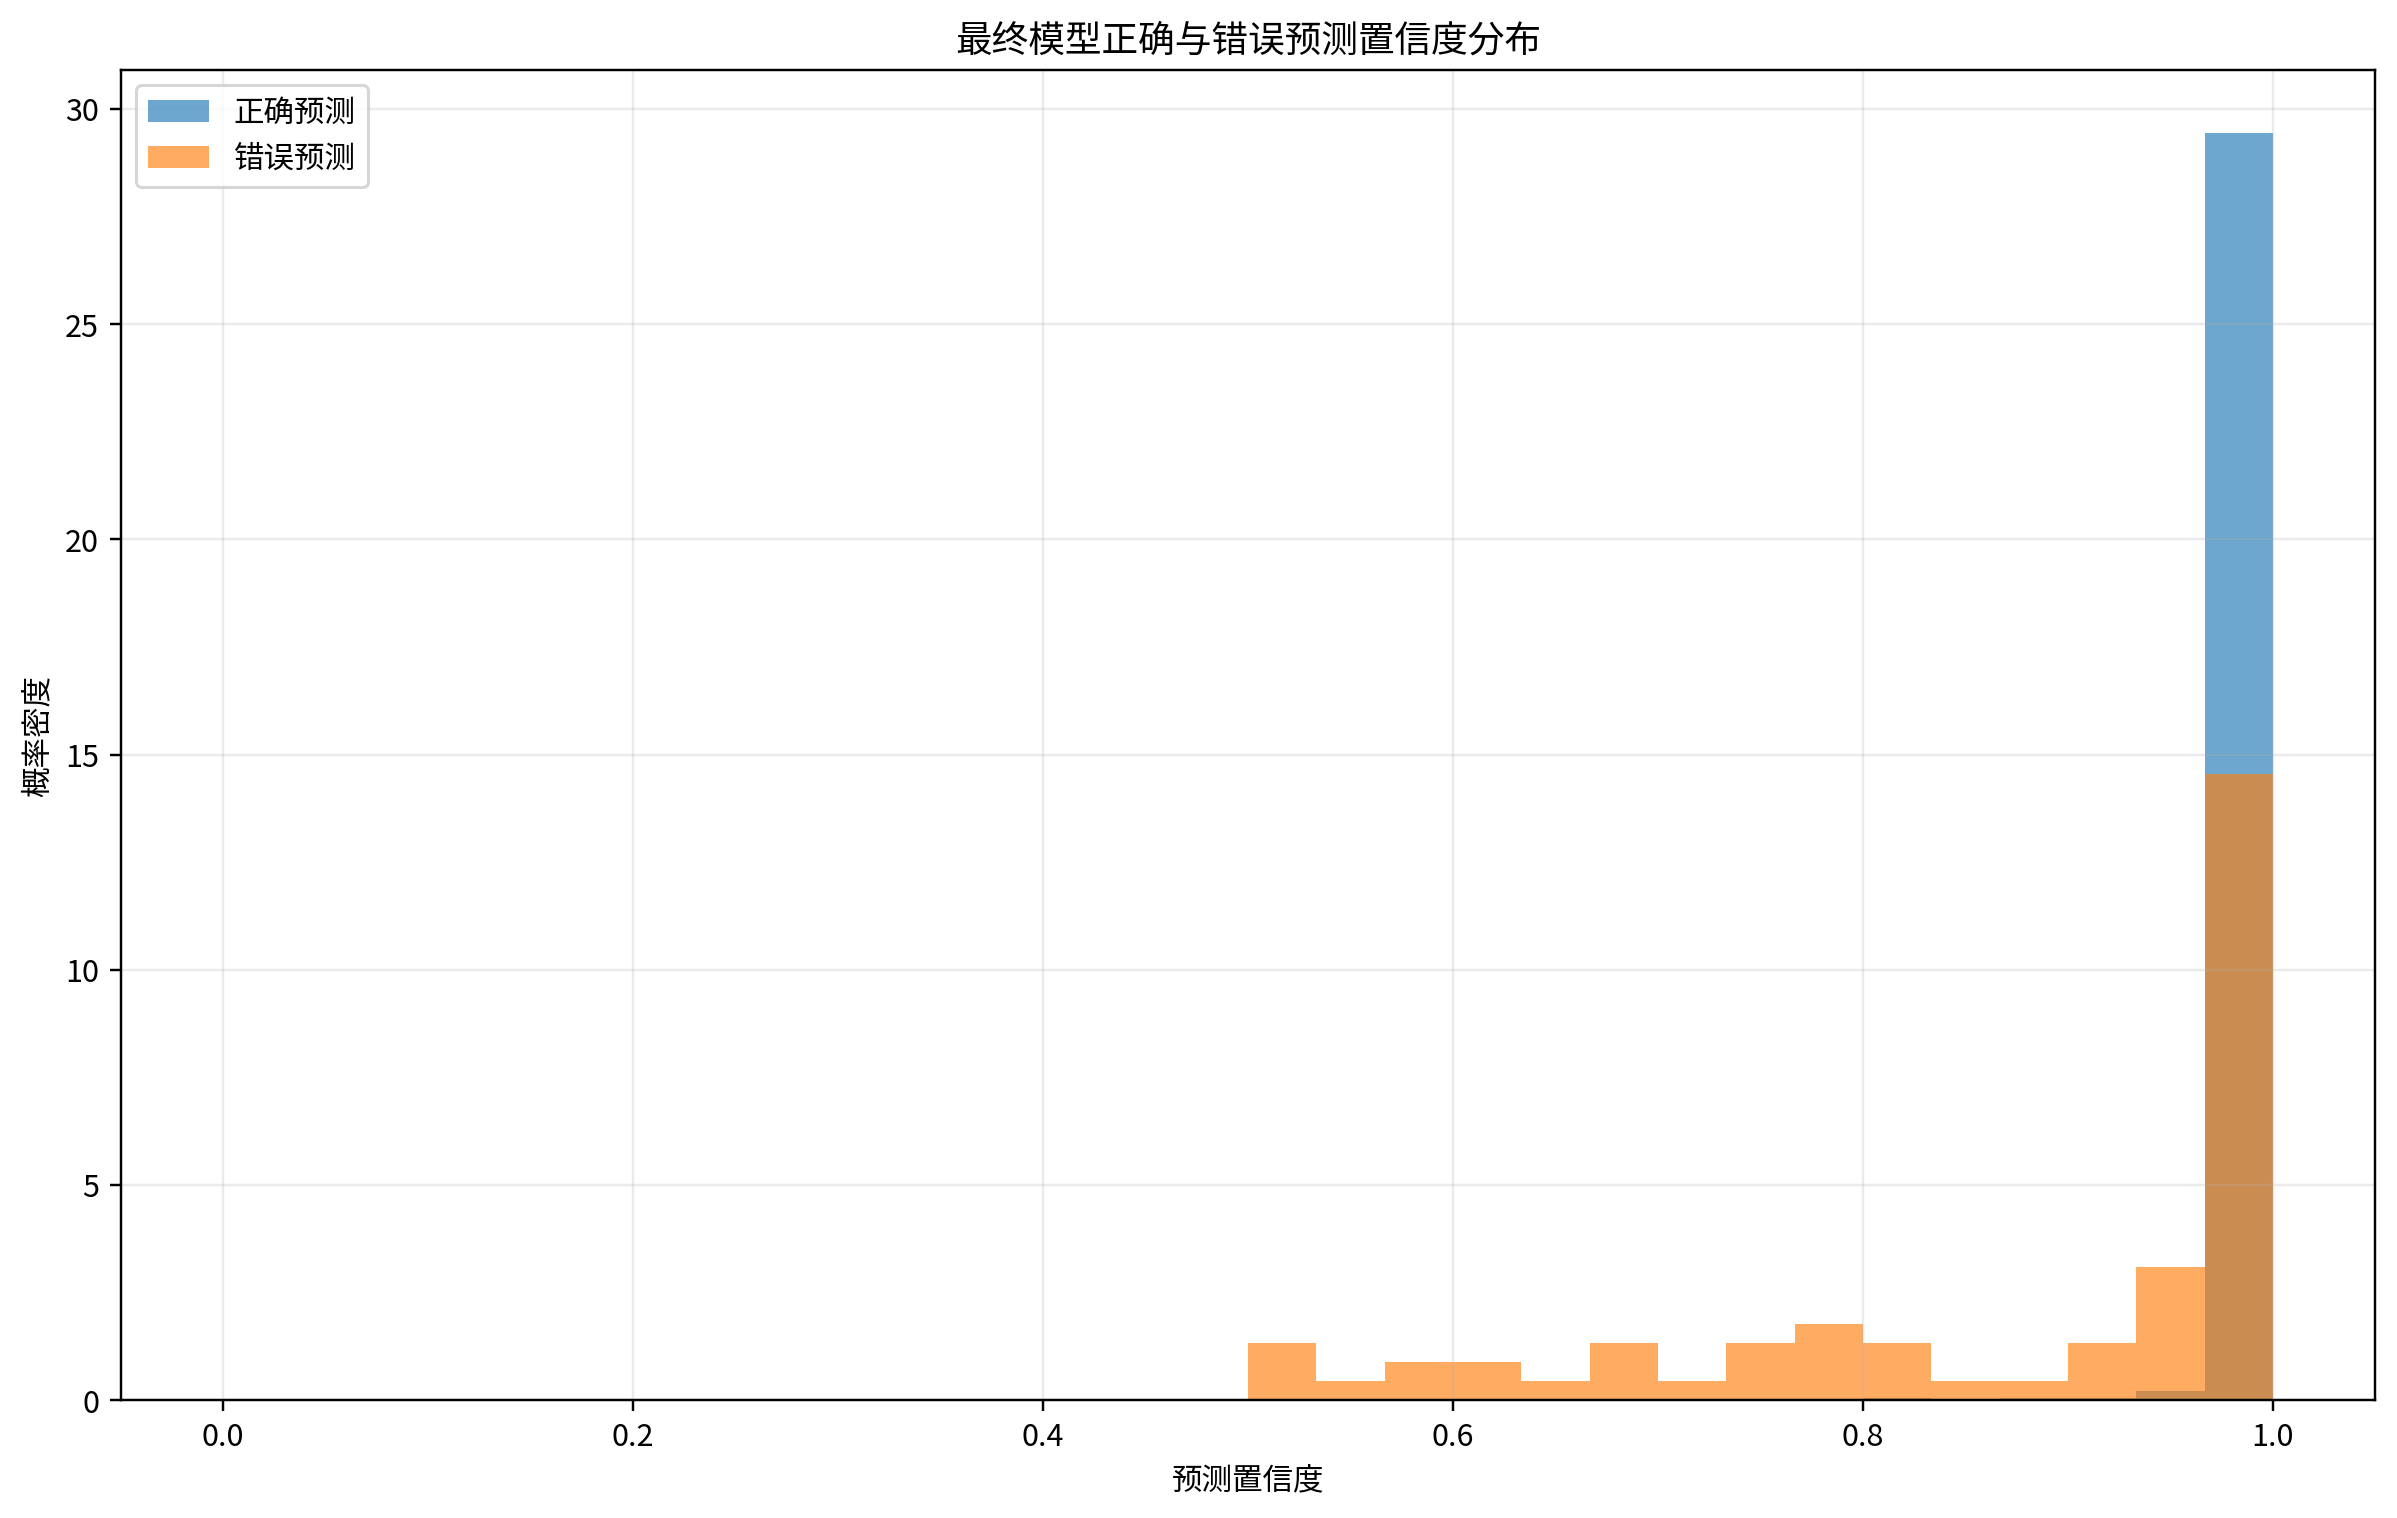

In [3]:
# ==========================================
# Cell 4：正确与错误预测置信度分析
# ==========================================
correct_confidence = prediction_df.loc[
    prediction_df["是否预测正确"], "预测置信度"
].to_numpy(dtype=float)
wrong_confidence = prediction_df.loc[
    ~prediction_df["是否预测正确"], "预测置信度"
].to_numpy(dtype=float)

def describe_confidence(values, label):
    values = np.asarray(values, dtype=float)
    return {
        "预测结果": label,
        "样本数量": int(len(values)),
        "平均置信度": float(values.mean()) if len(values) else np.nan,
        "中位数置信度": float(np.median(values)) if len(values) else np.nan,
        "最低置信度": float(values.min()) if len(values) else np.nan,
        "最高置信度": float(values.max()) if len(values) else np.nan,
    }

confidence_summary_df = pd.DataFrame([
    describe_confidence(correct_confidence, "正确预测"),
    describe_confidence(wrong_confidence, "错误预测"),
])
display(confidence_summary_df)
confidence_summary_df.to_csv(
    OUTPUT_DIR / "04_正确与错误预测置信度统计.csv",
    index=False,
    encoding="utf-8-sig",
)

plt.close("all")
figure, axis = plt.subplots(figsize=(11, 7))
bins = np.linspace(0, 1, 31)

if len(correct_confidence):
    axis.hist(
        correct_confidence,
        bins=bins,
        alpha=0.65,
        density=True,
        label="正确预测",
    )
if len(wrong_confidence):
    axis.hist(
        wrong_confidence,
        bins=bins,
        alpha=0.65,
        density=True,
        label="错误预测",
    )

axis.set_xlabel("预测置信度")
axis.set_ylabel("概率密度")
axis.set_title("最终模型正确与错误预测置信度分布")
axis.grid(alpha=0.25)
axis.legend()
figure.tight_layout()

CONFIDENCE_FIGURE_PATH = OUTPUT_DIR / "05_正确与错误预测置信度分布.png"
figure.savefig(CONFIDENCE_FIGURE_PATH, dpi=220, bbox_inches="tight")
plt.close(figure)

display(IPythonImage(filename=str(CONFIDENCE_FIGURE_PATH)))


In [4]:
# ==========================================
# Cell 5：样本网格绘制函数
# ==========================================
def load_image_safely(image_path):
    path = Path(str(image_path))
    if not path.is_file():
        return None
    try:
        with Image.open(path) as file:
            return file.convert("RGB").copy()
    except Exception as error:
        warnings.warn(f"图像读取失败：{path}\n{error}")
        return None

def save_sample_grid(
    dataframe,
    output_path,
    figure_title,
    title_builder,
    columns=5,
):
    dataframe = dataframe.reset_index(drop=True)
    if len(dataframe) == 0:
        print(f"{figure_title}：没有可展示样本，已跳过。")
        return False

    rows = int(np.ceil(len(dataframe) / columns))
    plt.close("all")
    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(18, 3.8 * rows),
    )
    axes = np.atleast_1d(axes).ravel()

    for index, axis in enumerate(axes):
        axis.axis("off")
        if index >= len(dataframe):
            continue

        row = dataframe.iloc[index]
        image = load_image_safely(row["图像路径"])
        if image is None:
            axis.text(
                0.5, 0.5, "图像缺失",
                ha="center", va="center",
                transform=axis.transAxes,
            )
            axis.set_title(title_builder(row), fontsize=9)
            continue

        axis.imshow(image)
        axis.set_title(title_builder(row), fontsize=10)

    figure.suptitle(
        figure_title,
        fontsize=21,
        fontweight="bold",
    )
    figure.tight_layout(rect=[0, 0, 1, 0.96])
    figure.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.close(figure)
    display(IPythonImage(filename=str(output_path)))
    return True

print("样本网格绘制函数已准备完成。")


样本网格绘制函数已准备完成。


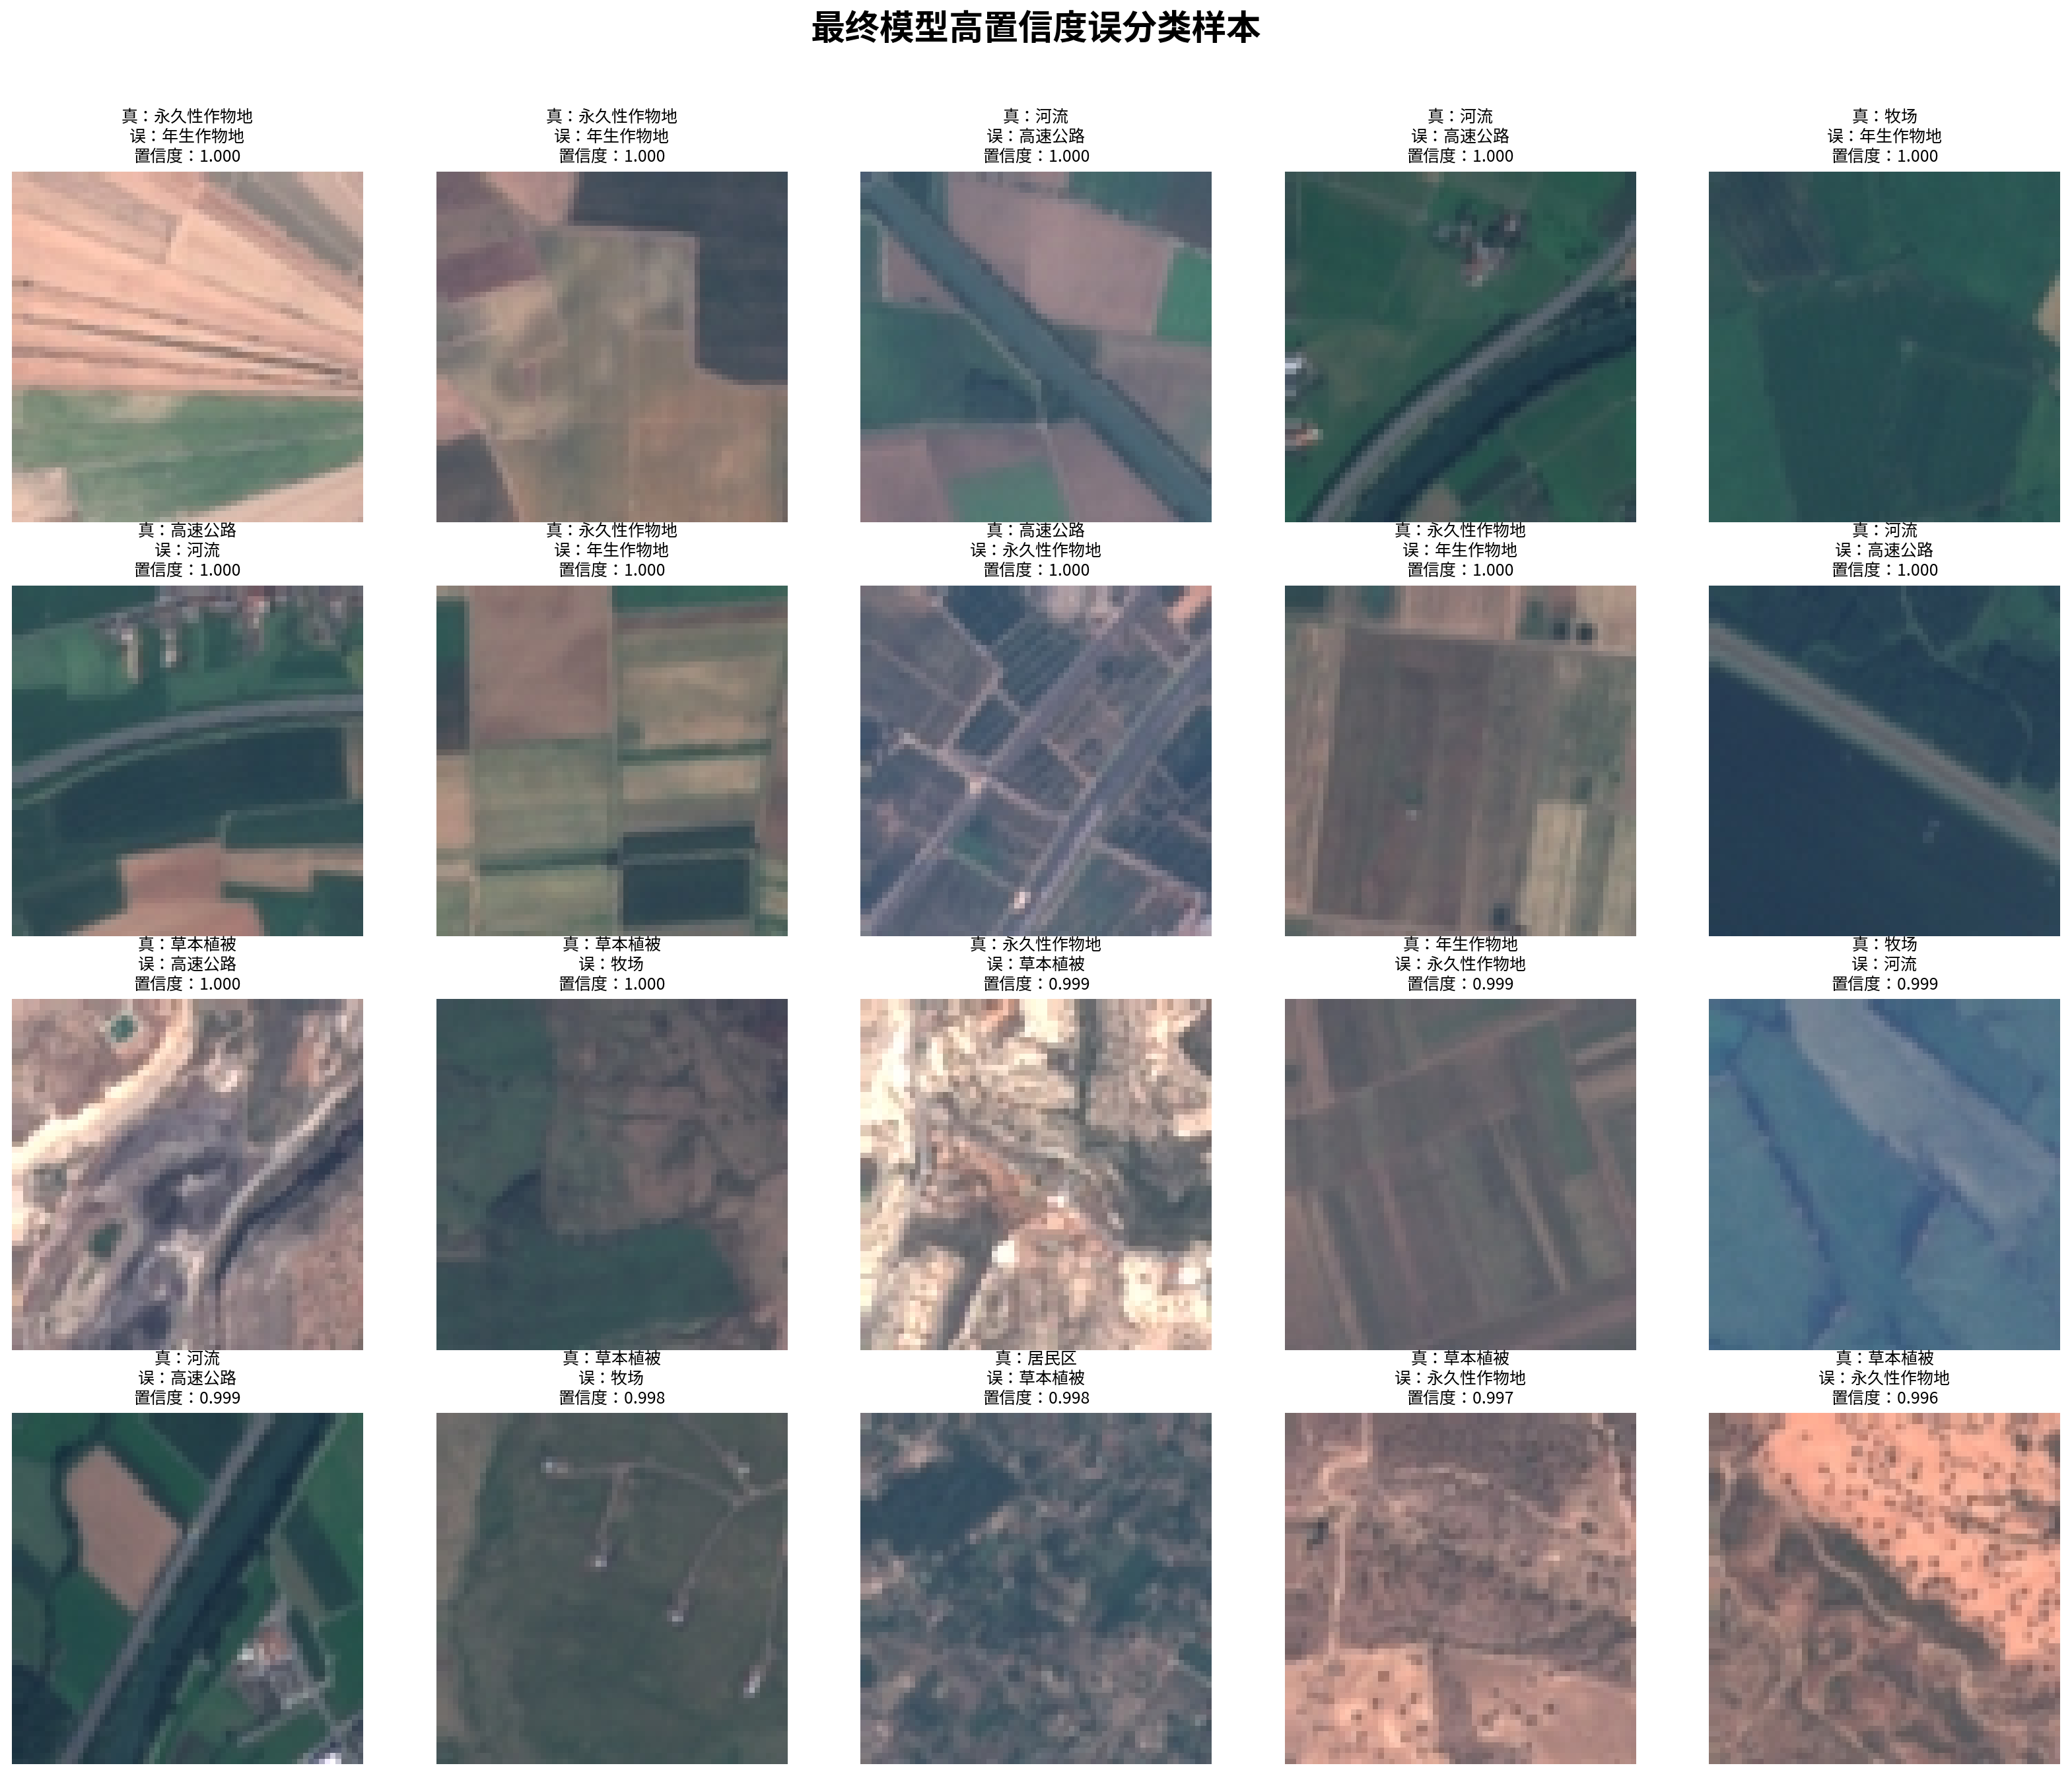

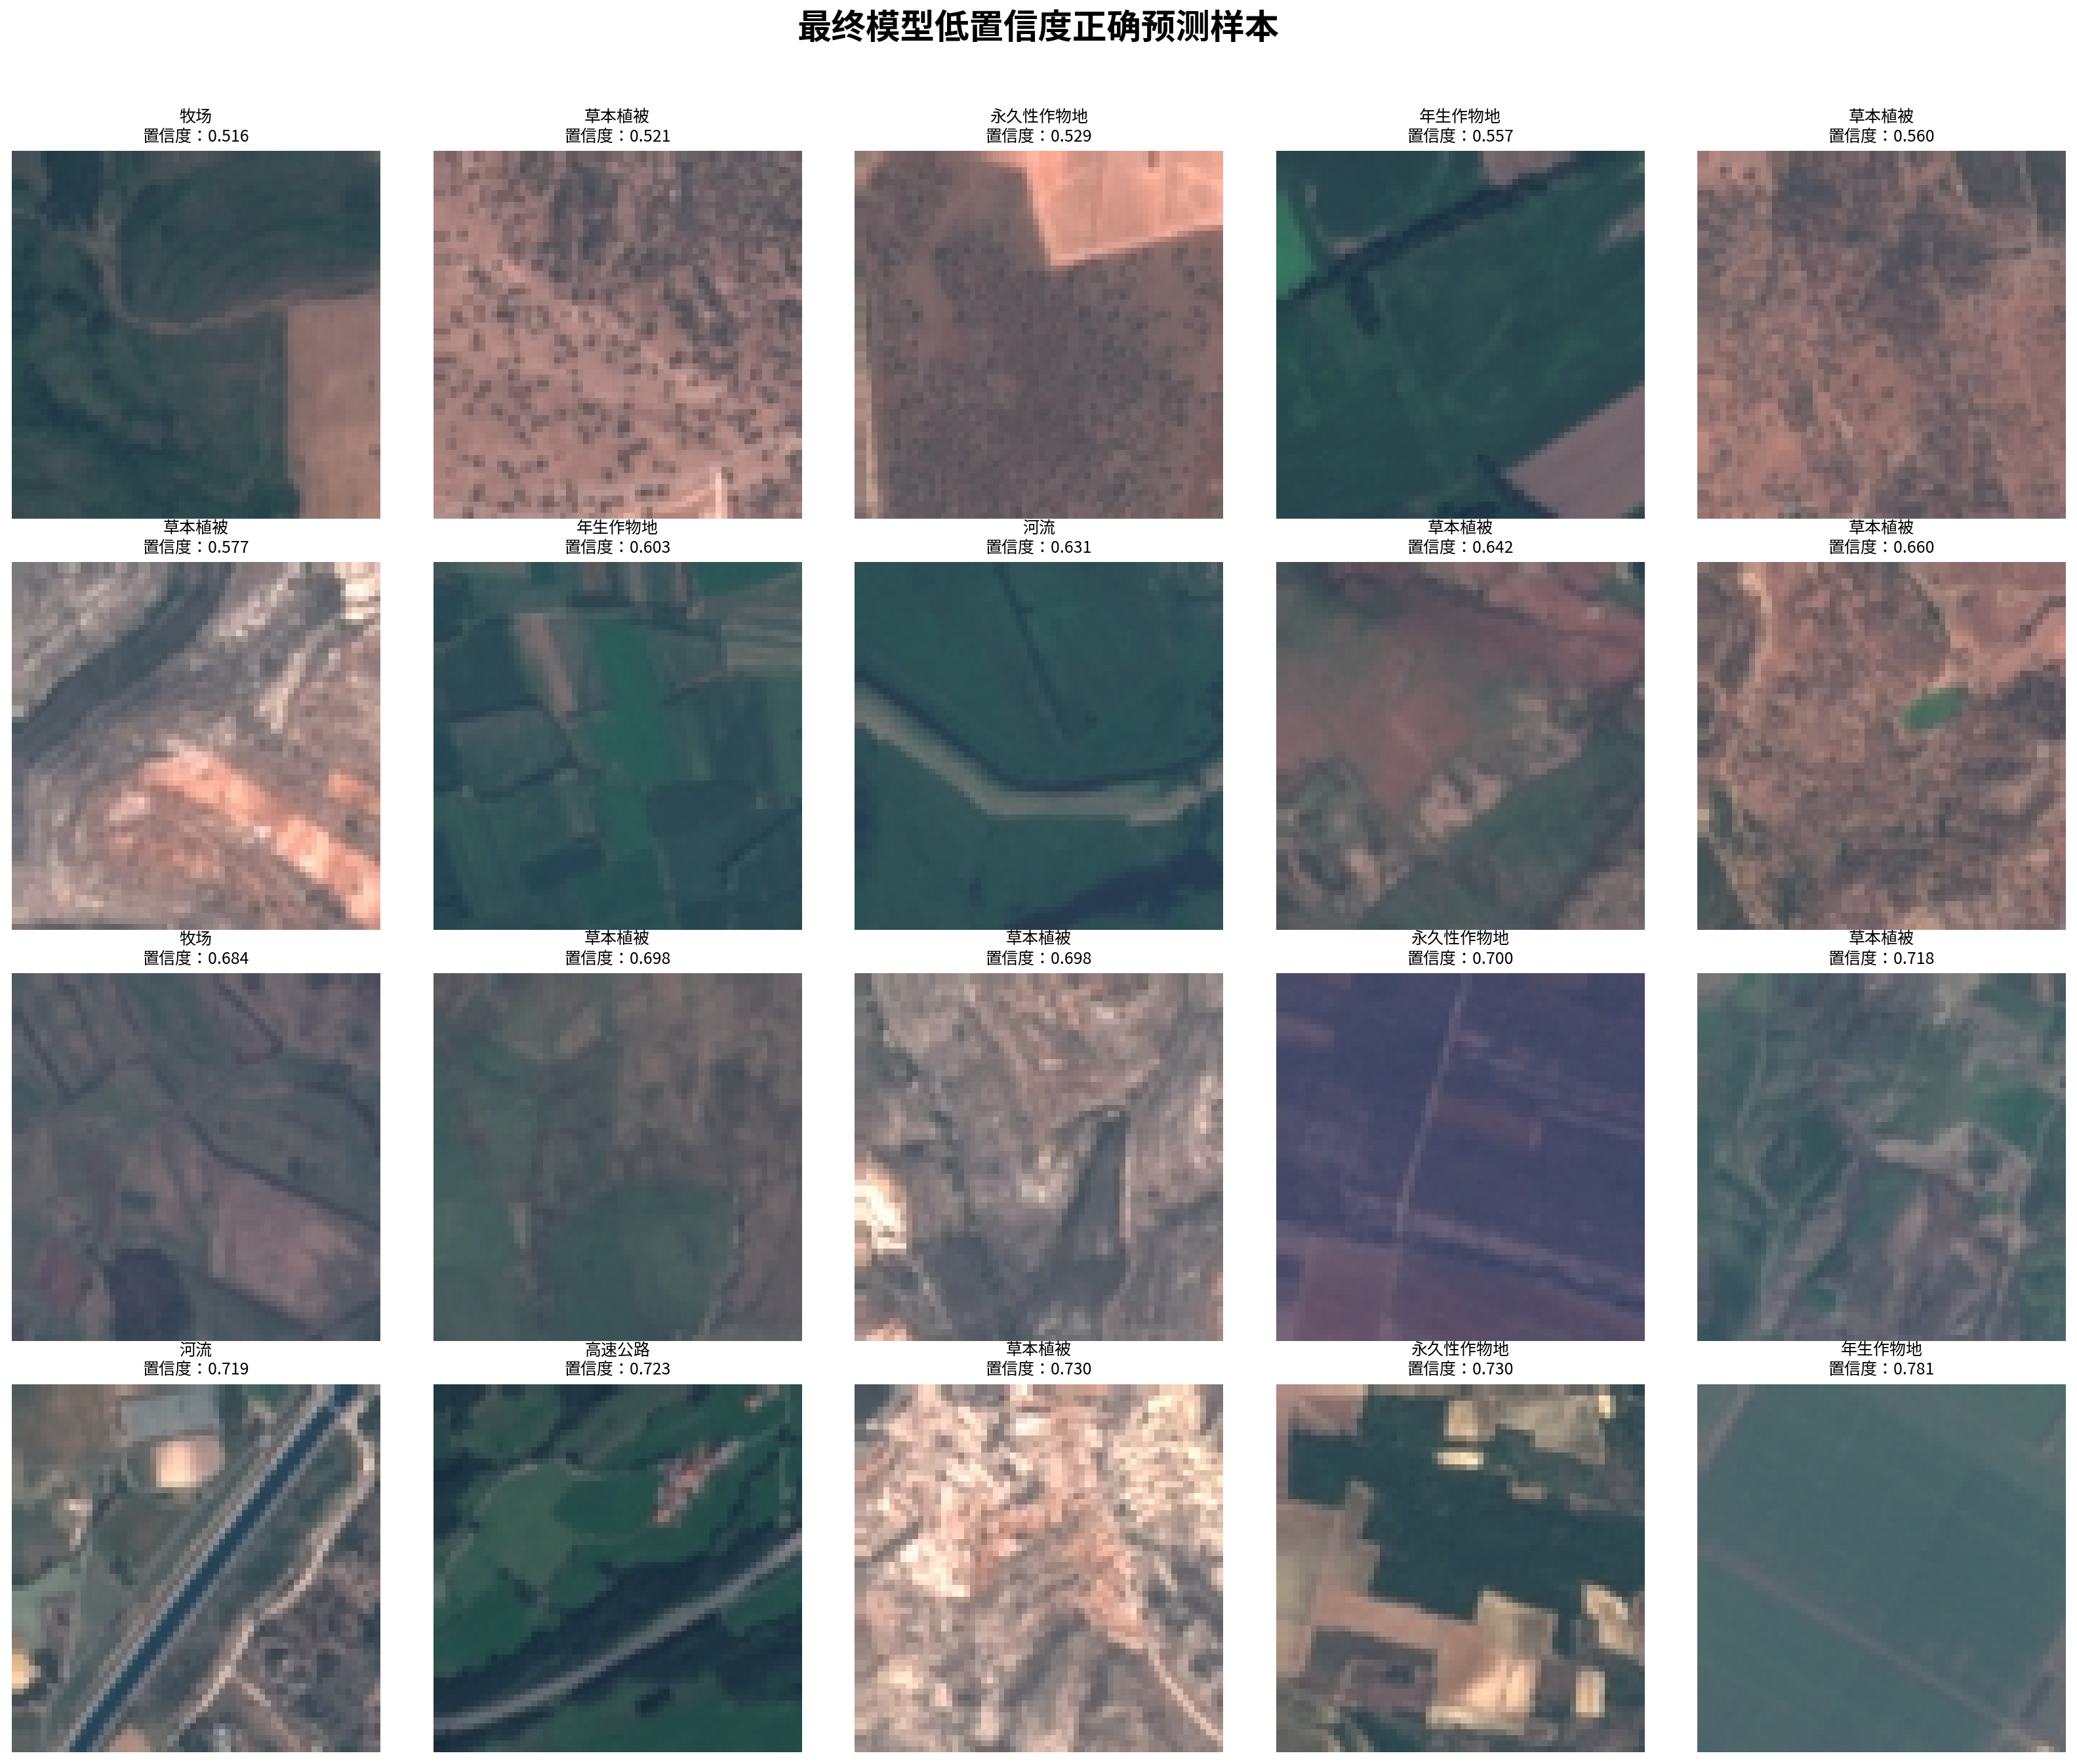

True

In [5]:
# ==========================================
# Cell 6：高置信度误分类与低置信度正确样本
# ==========================================
top_error_df = (
    error_df
    .sort_values("预测置信度", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top_error_df.to_csv(
    OUTPUT_DIR / "06_高置信度误分类样本.csv",
    index=False,
    encoding="utf-8-sig",
)

HIGH_ERROR_FIGURE_PATH = OUTPUT_DIR / "07_高置信度误分类样本网格.png"
save_sample_grid(
    top_error_df,
    HIGH_ERROR_FIGURE_PATH,
    "最终模型高置信度误分类样本",
    lambda row: (
        f"真：{row['真实类别中文名称']}\n"
        f"误：{row['预测类别中文名称']}\n"
        f"置信度：{float(row['预测置信度']):.3f}"
    ),
)

low_conf_correct_df = (
    prediction_df.loc[prediction_df["是否预测正确"]]
    .sort_values("预测置信度", ascending=True)
    .head(20)
    .reset_index(drop=True)
)
low_conf_correct_df.to_csv(
    OUTPUT_DIR / "08_低置信度正确预测样本.csv",
    index=False,
    encoding="utf-8-sig",
)

LOW_CORRECT_FIGURE_PATH = OUTPUT_DIR / "09_低置信度正确预测样本网格.png"
save_sample_grid(
    low_conf_correct_df,
    LOW_CORRECT_FIGURE_PATH,
    "最终模型低置信度正确预测样本",
    lambda row: (
        f"{row['真实类别中文名称']}\n"
        f"置信度：{float(row['预测置信度']):.3f}"
    ),
)


In [6]:
# ==========================================
# Cell 7：误分类分析总结与输出文件清单
# ==========================================
hardest_classes = class_error_df.head(3)[
    ["真实类别中文名称", "错误数量", "错误率"]
]

if len(confusion_pairs_df):
    top_pairs = confusion_pairs_df.head(5)[
        ["真实类别中文名称", "预测类别中文名称", "混淆数量"]
    ]
    top_pairs_text = top_pairs.to_string(index=False)
else:
    top_pairs_text = "未出现误分类。"

correct_mean_series = confidence_summary_df.loc[
    confidence_summary_df["预测结果"] == "正确预测",
    "平均置信度",
]
wrong_mean_series = confidence_summary_df.loc[
    confidence_summary_df["预测结果"] == "错误预测",
    "平均置信度",
]

correct_mean = (
    float(correct_mean_series.iloc[0])
    if len(correct_mean_series) and pd.notna(correct_mean_series.iloc[0])
    else np.nan
)
wrong_mean = (
    float(wrong_mean_series.iloc[0])
    if len(wrong_mean_series) and pd.notna(wrong_mean_series.iloc[0])
    else np.nan
)

summary = f"""
EuroSAT RGB最终模型误分类样本与类别混淆分析总结
============================================================

测试样本总数：{len(prediction_df):,}
正确预测数量：{int(prediction_df['是否预测正确'].sum()):,}
误分类数量：{int((~prediction_df['是否预测正确']).sum()):,}
总体错误率：{float((~prediction_df['是否预测正确']).mean()):.4%}

错误率最高的三个类别：
{hardest_classes.to_string(index=False)}

主要类别混淆方向：
{top_pairs_text}

正确预测平均置信度：
{correct_mean:.4f}

错误预测平均置信度：
{wrong_mean:.4f}

说明：
1. 本节只读取6.3.1保存的测试预测明细，不重新训练或推理；
2. 高置信度误分类用于观察模型稳定但错误的判断；
3. 低置信度正确样本用于观察模型决策边界附近的样本。
""".strip()

SUMMARY_PATH = OUTPUT_DIR / "10_误分类与类别混淆分析总结.txt"
SUMMARY_PATH.write_text(summary, encoding="utf-8")

output_manifest = pd.DataFrame([
    {
        "文件名称": path.name,
        "文件路径": str(path),
        "文件大小_KB": round(path.stat().st_size / 1024, 2),
    }
    for path in sorted(OUTPUT_DIR.iterdir())
    if path.is_file()
])
OUTPUT_MANIFEST_PATH = OUTPUT_DIR / "11_本节输出文件清单.csv"
output_manifest.to_csv(
    OUTPUT_MANIFEST_PATH,
    index=False,
    encoding="utf-8-sig",
)

print(summary)
print(f"\n总结已保存：{SUMMARY_PATH}")
print(f"输出清单已保存：{OUTPUT_MANIFEST_PATH}")
print("\n6.3.2执行完成。下一步运行6.3.3。")


EuroSAT RGB最终模型误分类样本与类别混淆分析总结

测试样本总数：4,050
正确预测数量：3,982
误分类数量：68
总体错误率：1.6790%

错误率最高的三个类别：
真实类别中文名称  错误数量      错误率
    草本植被    16 0.035556
  永久性作物地    13 0.034667
      河流     9 0.024000

主要类别混淆方向：
真实类别中文名称 预测类别中文名称  混淆数量
  永久性作物地    年生作物地     7
      河流     高速公路     7
    草本植被   永久性作物地     6
   年生作物地   永久性作物地     6
    草本植被       森林     5

正确预测平均置信度：
0.9967

错误预测平均置信度：
0.8768

说明：
1. 本节只读取6.3.1保存的测试预测明细，不重新训练或推理；
2. 高置信度误分类用于观察模型稳定但错误的判断；
3. 低置信度正确样本用于观察模型决策边界附近的样本。

总结已保存：/root/autodl-tmp/课设/results/06_模型训练与优化/6.3.2_误分类样本与类别混淆分析/10_误分类与类别混淆分析总结.txt
输出清单已保存：/root/autodl-tmp/课设/results/06_模型训练与优化/6.3.2_误分类样本与类别混淆分析/11_本节输出文件清单.csv

6.3.2执行完成。下一步运行6.3.3。
